# Torre de Transmissão — Minimização de Distâncias com Hill Climbing

## Problema

Posicionar uma **torre de transmissão** para atender a **três cidades** em coordenadas fixas,
minimizando a soma das distâncias euclidianas:

$$f(x, y) = \sqrt{(x-x_1)^2 + (y-y_1)^2} + \sqrt{(x-x_2)^2 + (y-y_2)^2} + \sqrt{(x-x_3)^2 + (y-y_3)^2}$$

Este é o **Problema de Weber** (ou Fermat-Torricelli generalizado).

---

## O que é Hill Climbing?

Hill Climbing é uma **heurística de busca local** simples e eficiente:
- Começa em uma solução inicial.
- A cada iteração, gera **vizinhos** da solução atual.
- **Move-se apenas para vizinhos melhores** (nunca aceita pioras).
- Para quando nenhum vizinho é melhor (convergência a um ótimo local).

### Variantes implementadas
| Variante | Estratégia |
|---|---|
| **Simple Hill Climbing** | Aceita o primeiro vizinho melhor encontrado |
| **Steepest Ascent (descida mais íngreme)** | Avalia todos os vizinhos e aceita o melhor |
| **Stochastic Hill Climbing** | Escolhe aleatoriamente um vizinho melhor |

> ⚠️ **Limitação principal**: Hill Climbing pode ficar preso em **ótimos locais**.  
> Para comparação, o Simulated Annealing (no outro notebook) contorna isso aceitando pioras com probabilidade controlada.

## 1. Importações

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42)

## 2. Definição do Problema

In [3]:
cidades = np.array([
    [1.0, 2.0],   # Cidade A
    [5.0, 8.0],   # Cidade B
    [9.0, 3.0],   # Cidade C
])

nomes_cidades = ['Cidade A', 'Cidade B', 'Cidade C']

def f(pos, cidades):
    """Função objetivo: soma das distâncias euclidianas às cidades."""
    return np.sum(np.sqrt(np.sum((pos - cidades)**2, axis=1)))

# Teste
pos_teste = np.array([5.0, 5.0])
print(f"f(5, 5) = {f(pos_teste, cidades):.4f}")

f(5, 5) = 12.4721


## 3. Algoritmos de Hill Climbing

### 3.1 Simple Hill Climbing

In [4]:
def simple_hill_climbing(f, cidades, T0=None, max_iter=10000, passo=0.5,
                          n_vizinhos=8, pos_inicial=None):
    """
    Simple Hill Climbing: aceita o PRIMEIRO vizinho melhor encontrado.

    Parâmetros
    ----------
    f          : função objetivo f(pos, cidades) -> float
    cidades    : array (n, 2) com coordenadas das cidades
    max_iter   : número máximo de iterações
    passo      : tamanho do passo para gerar vizinhos
    n_vizinhos : número de direções candidatas por iteração
    pos_inicial: posição inicial (None = média das cidades + ruído)

    Retorna
    -------
    melhor_pos   : melhor posição encontrada
    melhor_custo : menor custo encontrado
    historico    : lista de custos ao longo das iterações
    traj         : trajetória das posições aceitas
    """
    if pos_inicial is None:
        pos_atual = np.mean(cidades, axis=0) + np.random.uniform(-1, 1, 2)
    else:
        pos_atual = pos_inicial.copy()

    custo_atual = f(pos_atual, cidades)
    historico = [custo_atual]
    traj = [pos_atual.copy()]

    for _ in range(max_iter):
        melhorou = False

        # Gera vizinhos em direções aleatórias
        angulos = np.random.uniform(0, 2 * np.pi, n_vizinhos)
        for angulo in angulos:
            perturbacao = passo * np.array([np.cos(angulo), np.sin(angulo)])
            pos_nova = pos_atual + perturbacao
            custo_novo = f(pos_nova, cidades)

            # Aceita o PRIMEIRO vizinho melhor
            if custo_novo < custo_atual:
                pos_atual = pos_nova
                custo_atual = custo_novo
                traj.append(pos_atual.copy())
                melhorou = True
                break  # <- diferença do Steepest Ascent

        historico.append(custo_atual)

        # Critério de parada: nenhum vizinho melhora
        if not melhorou:
            break

    return pos_atual, custo_atual, historico, np.array(traj)

### 3.2 Steepest Ascent Hill Climbing (Descida mais íngreme)

In [5]:
def steepest_hill_climbing(f, cidades, max_iter=10000, passo=0.5,
                            n_vizinhos=16, pos_inicial=None):
    """
    Steepest Ascent Hill Climbing: avalia TODOS os vizinhos e aceita o MELHOR.

    Parâmetros
    ----------
    (idem ao simple_hill_climbing)

    Retorna
    -------
    melhor_pos   : melhor posição encontrada
    melhor_custo : menor custo encontrado
    historico    : lista de custos ao longo das iterações
    traj         : trajetória das posições aceitas
    """
    if pos_inicial is None:
        pos_atual = np.mean(cidades, axis=0) + np.random.uniform(-1, 1, 2)
    else:
        pos_atual = pos_inicial.copy()

    custo_atual = f(pos_atual, cidades)
    historico = [custo_atual]
    traj = [pos_atual.copy()]

    for _ in range(max_iter):
        melhor_vizinho = None
        melhor_custo_vizinho = custo_atual

        # Avalia TODOS os vizinhos (direções igualmente espaçadas)
        angulos = np.linspace(0, 2 * np.pi, n_vizinhos, endpoint=False)
        for angulo in angulos:
            perturbacao = passo * np.array([np.cos(angulo), np.sin(angulo)])
            pos_nova = pos_atual + perturbacao
            custo_novo = f(pos_nova, cidades)

            if custo_novo < melhor_custo_vizinho:
                melhor_vizinho = pos_nova
                melhor_custo_vizinho = custo_novo

        # Aceita o MELHOR vizinho (se houver melhora)
        if melhor_vizinho is not None:
            pos_atual = melhor_vizinho
            custo_atual = melhor_custo_vizinho
            traj.append(pos_atual.copy())
        else:
            break  # Ótimo local: nenhum vizinho melhora

        historico.append(custo_atual)

    return pos_atual, custo_atual, historico, np.array(traj)

### 3.3 Stochastic Hill Climbing

In [6]:
def stochastic_hill_climbing(f, cidades, max_iter=10000, passo=0.5,
                               pos_inicial=None):
    """
    Stochastic Hill Climbing: gera UM vizinho aleatório por iteração.
    Aceita apenas se for melhor que o atual.

    Parâmetros
    ----------
    (idem ao simple_hill_climbing)

    Retorna
    -------
    melhor_pos   : melhor posição encontrada
    melhor_custo : menor custo encontrado
    historico    : lista de custos ao longo das iterações
    traj         : trajetória das posições aceitas
    """
    if pos_inicial is None:
        pos_atual = np.mean(cidades, axis=0) + np.random.uniform(-1, 1, 2)
    else:
        pos_atual = pos_inicial.copy()

    custo_atual = f(pos_atual, cidades)
    historico = [custo_atual]
    traj = [pos_atual.copy()]
    iter_sem_melhora = 0

    for _ in range(max_iter):
        # Gera UM vizinho aleatório
        perturbacao = np.random.uniform(-passo, passo, 2)
        pos_nova = pos_atual + perturbacao
        custo_novo = f(pos_nova, cidades)

        if custo_novo < custo_atual:
            pos_atual = pos_nova
            custo_atual = custo_novo
            traj.append(pos_atual.copy())
            iter_sem_melhora = 0
        else:
            iter_sem_melhora += 1

        historico.append(custo_atual)

        # Para se ficar muito tempo sem melhorar
        if iter_sem_melhora > 500:
            break

    return pos_atual, custo_atual, historico, np.array(traj)

## 4. Execução e Resultados

In [7]:
from scipy.optimize import minimize

# Referência analítica (L-BFGS-B)
res = minimize(f, np.mean(cidades, axis=0), args=(cidades,), method='L-BFGS-B')
pos_ref   = res.x
custo_ref = res.fun

# Mesma posição inicial para comparação justa
np.random.seed(42)
pos_ini = np.mean(cidades, axis=0) + np.random.uniform(-1, 1, 2)

# Executa as três variantes
pos_shc, custo_shc, hist_shc, traj_shc = simple_hill_climbing(
    f, cidades, max_iter=5000, passo=0.3, n_vizinhos=8, pos_inicial=pos_ini.copy())

pos_stpst, custo_stpst, hist_stpst, traj_stpst = steepest_hill_climbing(
    f, cidades, max_iter=5000, passo=0.3, n_vizinhos=16, pos_inicial=pos_ini.copy())

pos_sthc, custo_sthc, hist_sthc, traj_sthc = stochastic_hill_climbing(
    f, cidades, max_iter=10000, passo=0.3, pos_inicial=pos_ini.copy())

print("=" * 55)
print("         RESULTADOS — HILL CLIMBING")
print("=" * 55)
print(f"  Referência (L-BFGS-B):     f = {custo_ref:.6f}")
print(f"  Simple HC:      x=({pos_shc[0]:.4f}, {pos_shc[1]:.4f})  f = {custo_shc:.6f}")
print(f"  Steepest HC:    x=({pos_stpst[0]:.4f}, {pos_stpst[1]:.4f})  f = {custo_stpst:.6f}")
print(f"  Stochastic HC:  x=({pos_sthc[0]:.4f}, {pos_sthc[1]:.4f})  f = {custo_sthc:.6f}")
print("=" * 55)

         RESULTADOS — HILL CLIMBING
  Referência (L-BFGS-B):     f = 12.458340
  Simple HC:      x=(5.1718, 4.9678)  f = 12.461146
  Steepest HC:    x=(5.1733, 4.8105)  f = 12.459024
  Stochastic HC:  x=(5.2151, 4.8448)  f = 12.458345


## 5. Visualizações

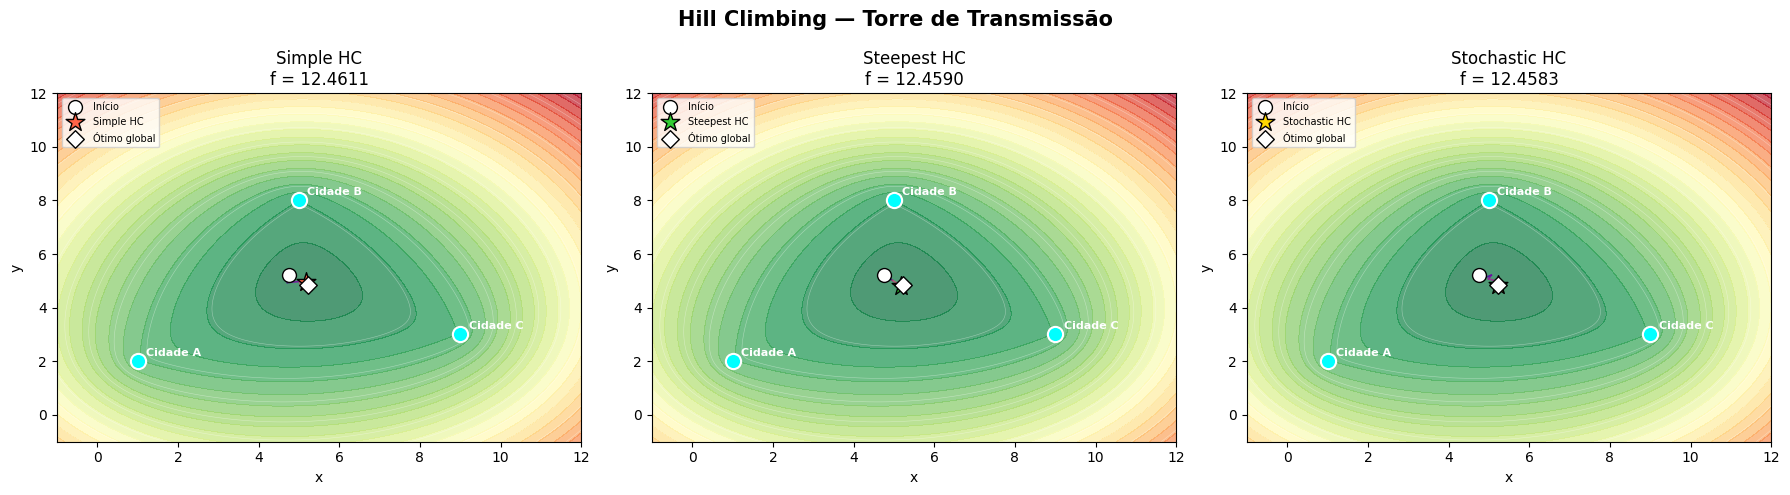

Figura salva em hc_trajetorias.png


In [8]:
# Grade para superfície
xs = np.linspace(-1, 12, 300)
ys = np.linspace(-1, 12, 300)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = f(np.array([X[i, j], Y[i, j]]), cidades)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hill Climbing — Torre de Transmissão', fontsize=15, fontweight='bold')

algoritmos = [
    ('Simple HC',     pos_shc,    traj_shc,    hist_shc,    'tomato'),
    ('Steepest HC',   pos_stpst,  traj_stpst,  hist_stpst,  'limegreen'),
    ('Stochastic HC', pos_sthc,   traj_sthc,   hist_sthc,   'gold'),
]

for ax, (nome, pos, traj, hist, cor) in zip(axes, algoritmos):
    cp = ax.contourf(X, Y, Z, levels=30, cmap='RdYlGn_r', alpha=0.7)
    ax.contour(X, Y, Z, levels=15, colors='white', linewidths=0.4, alpha=0.4)

    # Trajetória
    n_traj = len(traj)
    cores_traj = plt.cm.plasma(np.linspace(0, 1, max(n_traj, 2)))
    for i in range(n_traj - 1):
        ax.plot(traj[i:i+2, 0], traj[i:i+2, 1],
                color=cores_traj[i], linewidth=1.2, alpha=0.8)

    # Início
    ax.scatter(traj[0, 0], traj[0, 1], s=100, color='white', marker='o',
               zorder=5, edgecolors='black', label='Início')

    # Cidades
    for i, (cx, cy) in enumerate(cidades):
        ax.scatter(cx, cy, s=120, color='cyan', zorder=5,
                   edgecolors='white', linewidths=1.5)
        ax.annotate(nomes_cidades[i], (cx, cy), textcoords='offset points',
                    xytext=(6, 4), fontsize=8, color='white', fontweight='bold')

    # Torre encontrada
    ax.scatter(*pos, s=200, color=cor, marker='*', zorder=6,
               edgecolors='black', linewidths=1, label=f'{nome}')

    # Referência analítica
    ax.scatter(*pos_ref, s=80, color='white', marker='D', zorder=6,
               edgecolors='black', linewidths=1, label='Ótimo global')

    ax.set_title(f'{nome}\nf = {f(pos, cidades):.4f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig('hc_trajetorias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em hc_trajetorias.png')

## 6. Convergência Comparativa

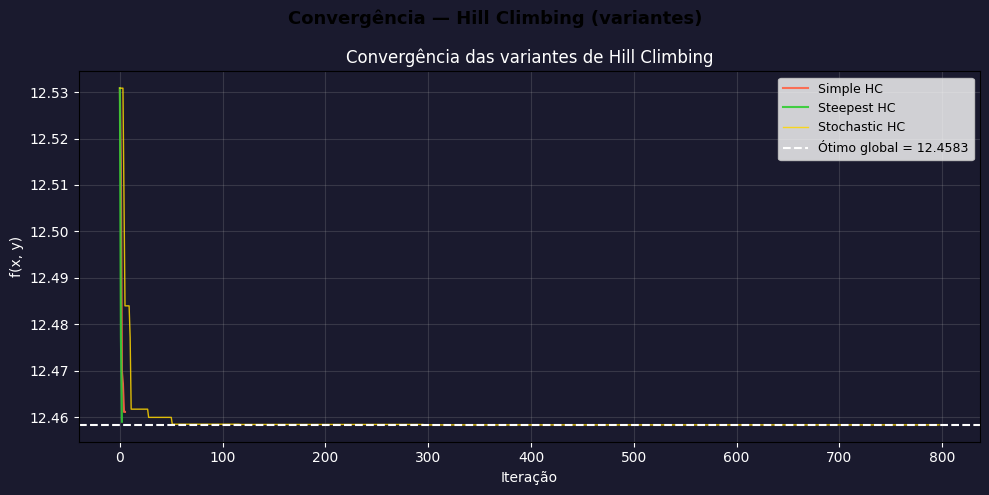

Figura salva em hc_convergencia.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Convergência — Hill Climbing (variantes)', fontsize=13, fontweight='bold')

ax.plot(hist_shc,   color='tomato',    linewidth=1.5, label='Simple HC',     alpha=0.9)
ax.plot(hist_stpst, color='limegreen', linewidth=1.5, label='Steepest HC',   alpha=0.9)
ax.plot(hist_sthc,  color='gold',      linewidth=1.0, label='Stochastic HC', alpha=0.85)
ax.axhline(custo_ref, color='white', linestyle='--', linewidth=1.5,
           label=f'Ótimo global = {custo_ref:.4f}')

ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

ax.set_xlabel('Iteração')
ax.set_ylabel('f(x, y)')
ax.set_title('Convergência das variantes de Hill Climbing', color='white')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('hc_convergencia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em hc_convergencia.png')

## 7. Problema dos Ótimos Locais

Para funções **multimodais** (múltiplos mínimos locais), o Hill Climbing fica preso.
O experimento abaixo executa **múltiplas inicializações aleatórias** e mostra
quão frequentemente cada variante encontra (ou não) o ótimo global.

In [10]:
N_RUNS = 30
TOLERANCIA = 0.01  # diferença máxima do ótimo global para considerar "encontrado"

resultados = {'Simple HC': [], 'Steepest HC': [], 'Stochastic HC': []}

for _ in range(N_RUNS):
    # Posição inicial aleatória diferente a cada corrida
    pos_rand = np.random.uniform(-2, 12, 2)

    _, c_s, _, _  = simple_hill_climbing(
        f, cidades, max_iter=5000, passo=0.3, n_vizinhos=8, pos_inicial=pos_rand.copy())
    _, c_st, _, _ = steepest_hill_climbing(
        f, cidades, max_iter=5000, passo=0.3, n_vizinhos=16, pos_inicial=pos_rand.copy())
    _, c_sc, _, _ = stochastic_hill_climbing(
        f, cidades, max_iter=10000, passo=0.3, pos_inicial=pos_rand.copy())

    resultados['Simple HC'].append(c_s)
    resultados['Steepest HC'].append(c_st)
    resultados['Stochastic HC'].append(c_sc)

print("=" * 55)
print(f"  Ótimo global (referência): {custo_ref:.6f}")
print("=" * 55)
for nome, custos in resultados.items():
    acertos = sum(abs(c - custo_ref) <= TOLERANCIA for c in custos)
    media = np.mean(custos)
    desvio = np.std(custos)
    print(f"  {nome:15s}: acertos={acertos}/{N_RUNS}  média={media:.4f}  std={desvio:.4f}")
print("=" * 55)

  Ótimo global (referência): 12.458340
  Simple HC      : acertos=24/30  média=12.5977  std=0.5063
  Steepest HC    : acertos=30/30  média=12.4597  std=0.0010
  Stochastic HC  : acertos=30/30  média=12.4584  std=0.0000


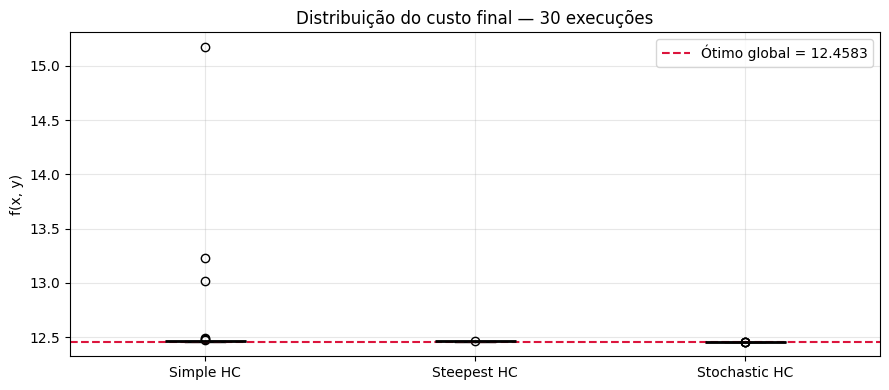

Figura salva em hc_robustez.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = list(resultados.keys())
dados  = [resultados[k] for k in labels]
cores  = ['tomato', 'limegreen', 'gold']

bp = ax.boxplot(dados, tick_labels=labels, patch_artist=True)
for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.8)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.axhline(custo_ref, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Ótimo global = {custo_ref:.4f}')
ax.set_title(f'Distribuição do custo final — {N_RUNS} execuções')
ax.set_ylabel('f(x, y)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hc_robustez.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em hc_robustez.png')

## 8. Resumo Final

In [12]:
print("\n" + "=" * 55)
print("         RESUMO FINAL")
print("=" * 55)
print(f"  Cidades:")
for cidade, nome in zip(cidades, nomes_cidades):
    print(f"    {nome}: ({cidade[0]:.1f}, {cidade[1]:.1f})")

print(f"\n  Referência (L-BFGS-B): ({pos_ref[0]:.4f}, {pos_ref[1]:.4f})  f = {custo_ref:.6f}")
print()

for nome, pos, custo in [
    ('Simple HC',     pos_shc,    custo_shc),
    ('Steepest HC',   pos_stpst,  custo_stpst),
    ('Stochastic HC', pos_sthc,   custo_sthc),
]:
    erro = abs(custo - custo_ref) / custo_ref * 100
    print(f"  {nome:15s}: ({pos[0]:.4f}, {pos[1]:.4f})  "
          f"f = {custo:.6f}  erro = {erro:.4f}%")

print("=" * 55)


         RESUMO FINAL
  Cidades:
    Cidade A: (1.0, 2.0)
    Cidade B: (5.0, 8.0)
    Cidade C: (9.0, 3.0)

  Referência (L-BFGS-B): (5.2199, 4.8448)  f = 12.458340

  Simple HC      : (5.1718, 4.9678)  f = 12.461146  erro = 0.0225%
  Steepest HC    : (5.1733, 4.8105)  f = 12.459024  erro = 0.0055%
  Stochastic HC  : (5.2151, 4.8448)  f = 12.458345  erro = 0.0000%
